This cell loads the collected Sydney housing dataset and performs basic data cleaning. Text fields are stripped of unnecessary spaces, the sale date is converted into a date format, and numerical variables are converted to numeric types. Missing values are also checked before further analysis.

In [21]:
import pandas as pd
import numpy as np

df = pd.read_csv("sydney_housing.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

df.columns = df.columns.str.strip()

df["suburb"] = df["suburb"].str.strip()
df["address"] = df["address"].str.strip()
df["property_type"] = df["property_type"].str.strip()

df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")
df["sale_price"] = pd.to_numeric(df["sale_price"], errors="coerce")

df["bedrooms"] = pd.to_numeric(df["bedrooms"], errors="coerce")
df["bathrooms"] = pd.to_numeric(df["bathrooms"], errors="coerce")

print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (272, 9)

Missing values:
suburb           167
address          167
sale_date        168
sale_price       167
property_type    167
bedrooms         167
bathrooms        167
parking          167
land_size        168
dtype: int64

Data types:
suburb                   object
address                  object
sale_date        datetime64[ns]
sale_price              float64
property_type            object
bedrooms                float64
bathrooms               float64
parking                 float64
land_size                object
dtype: object


In [22]:
print(df["suburb"].value_counts())

suburb
Beverly Hills    35
Concord          35
Castle Hill      35
Name: count, dtype: int64


In [23]:
print(df.groupby("suburb")["sale_price"].agg(["count", "mean", "median", "min", "max"]).round(2))

               count        mean     median       min        max
suburb                                                          
Beverly Hills     35  1463571.43  1570000.0  570000.0  2400000.0
Castle Hill       35  2100714.29  2312000.0  632000.0  5200000.0
Concord           35  2979822.17  3150000.0  498000.0  6900000.0


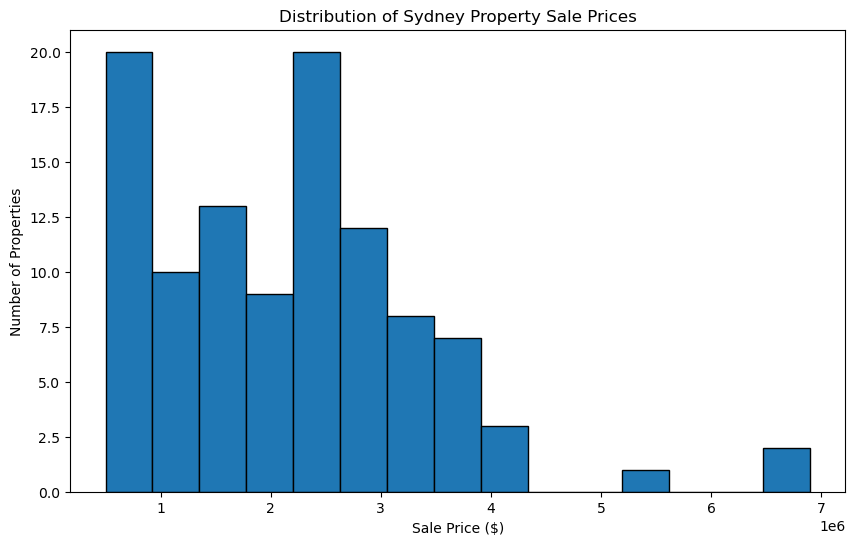

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df["sale_price"], bins=15, edgecolor="black")

plt.title("Distribution of Sydney Property Sale Prices")
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Properties")

plt.show()

<Figure size 1000x600 with 0 Axes>

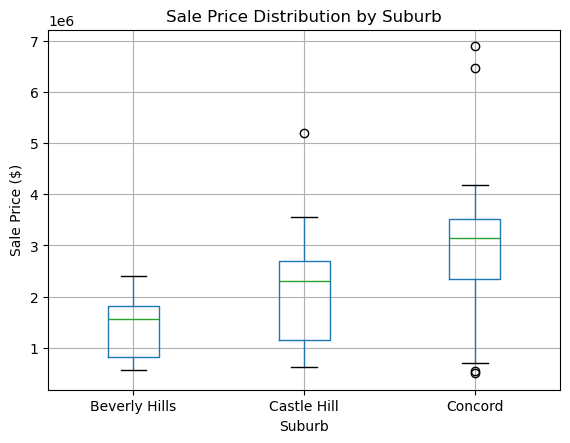

In [18]:
plt.figure(figsize=(10, 6))
df.boxplot(column="sale_price", by="suburb")
plt.title("Sale Price Distribution by Suburb")
plt.suptitle("")
plt.xlabel("Suburb")
plt.ylabel("Sale Price ($)")
plt.show()

The boxplot indicates clear differences in sale prices between the three suburbs. Concord has the highest typical sale prices, followed by Castle Hill and Beverly Hills. There is also substantial variation within each suburb, with several high-priced properties appearing as potential outliers. These differences suggest that suburb location is likely to be an important variable when predicting property sale prices.

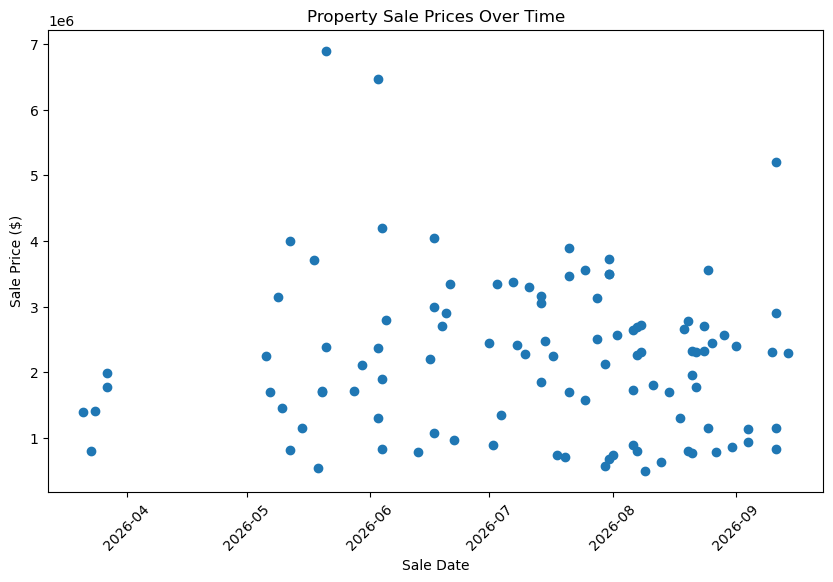

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(df["sale_date"], df["sale_price"])

plt.title("Property Sale Prices Over Time")
plt.xlabel("Sale Date")
plt.ylabel("Sale Price ($)")

plt.xticks(rotation=45)
plt.show()

In [25]:
Q1 = df["sale_price"].quantile(0.25)
Q3 = df["sale_price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["sale_price"] < lower_bound) | (df["sale_price"] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nPotential outliers:")
print(outliers[["suburb","address","sale_price","property_type","bedrooms","bathrooms"]].to_string(index=False))

Q1: 1150000.0
Q3: 2776000.0
IQR: 1626000.0
Lower bound: -1289000.0
Upper bound: 5215000.0

Potential outliers:
 suburb             address  sale_price property_type  bedrooms  bathrooms
Concord 30 Macnamara Avenue   6475000.0         House       5.0        5.0
Concord    20 Anderson Road   6900000.0         House       5.0        5.0


In [27]:
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
df["sale_year"] = df["sale_date"].dt.year
df["sale_month"] = df["sale_date"].dt.month
df["days_since_first_sale"] = (df["sale_date"] - df["sale_date"].min()).dt.days

print(df[["sale_date","bedrooms","bathrooms","total_rooms","sale_month","days_since_first_sale"]].head())

   sale_date  bedrooms  bathrooms  total_rooms  sale_month  \
0 2026-09-11       3.0        2.0          5.0         9.0   
1 2026-09-01       5.0        2.0          7.0         9.0   
2 2026-08-27       2.0        1.0          3.0         8.0   
3 2026-08-22       4.0        2.0          6.0         8.0   
4 2026-08-21       2.0        1.0          3.0         8.0   

   days_since_first_sale  
0                  174.0  
1                  164.0  
2                  159.0  
3                  154.0  
4                  153.0  


In [28]:
print(df.columns.tolist())

['suburb', 'address', 'sale_date', 'sale_price', 'property_type', 'bedrooms', 'bathrooms', 'parking', 'land_size', 'total_rooms', 'sale_year', 'sale_month', 'days_since_first_sale']


In [29]:
numeric_cols = [
    "sale_price",
    "bedrooms",
    "bathrooms",
    "total_rooms",
    "sale_month",
    "days_since_first_sale"
]

correlation = df[numeric_cols].corr()

print(correlation["sale_price"].sort_values(ascending=False))

sale_price               1.000000
total_rooms              0.732410
bathrooms                0.692425
bedrooms                 0.674157
sale_month              -0.046647
days_since_first_sale   -0.047626
Name: sale_price, dtype: float64


In [30]:
print(df.groupby("property_type")["sale_price"].agg(["count", "mean", "median", "min", "max"]).sort_values("mean", ascending=False)
      .round(2))

               count        mean     median        min        max
property_type                                                    
House             62  2781546.58  2515000.0  1150000.0  6900000.0
Duplex             8  2309486.00  2270444.0  1300000.0  3380000.0
Semi-detached      3  2150000.00  2280000.0  1800000.0  2370000.0
Townhouse          2  1669500.00  1669500.0  1450000.0  1889000.0
Villa              2  1280000.00  1280000.0  1150000.0  1410000.0
Apartment         28   920107.14   813000.0   498000.0  2500000.0


<Figure size 1000x600 with 0 Axes>

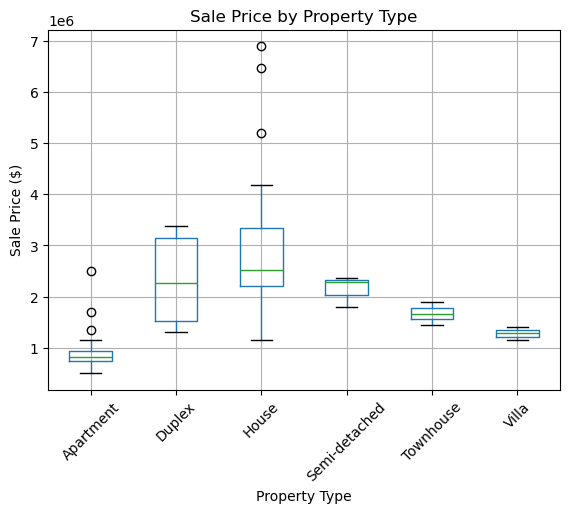

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df.boxplot(column="sale_price",by="property_type",rot=45)
plt.xlabel("Property Type")
plt.ylabel("Sale Price ($)")
plt.title("Sale Price by Property Type")
plt.suptitle("")
plt.show()

In [34]:
suburb_stats = (df.groupby("suburb")["sale_price"].agg(["count", "mean", "median", "min", "max"]).sort_values("mean", ascending=False)
      .round(2))
print(suburb_stats)

               count        mean     median       min        max
suburb                                                          
Concord           35  2979822.17  3150000.0  498000.0  6900000.0
Castle Hill       35  2100714.29  2312000.0  632000.0  5200000.0
Beverly Hills     35  1463571.43  1570000.0  570000.0  2400000.0


<Figure size 1000x600 with 0 Axes>

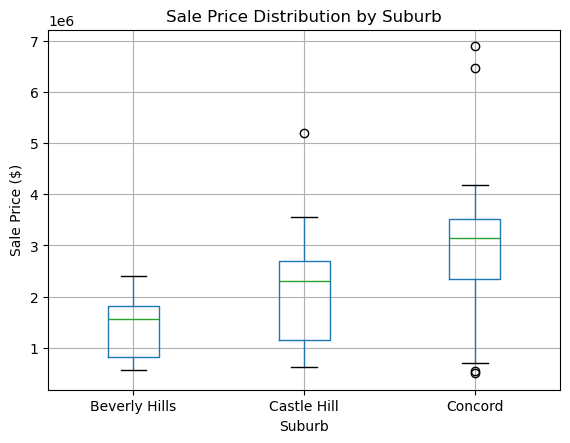

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

df.boxplot(column="sale_price",by="suburb")
plt.xlabel("Suburb")
plt.ylabel("Sale Price ($)")
plt.title("Sale Price Distribution by Suburb")
plt.suptitle("")
plt.show()

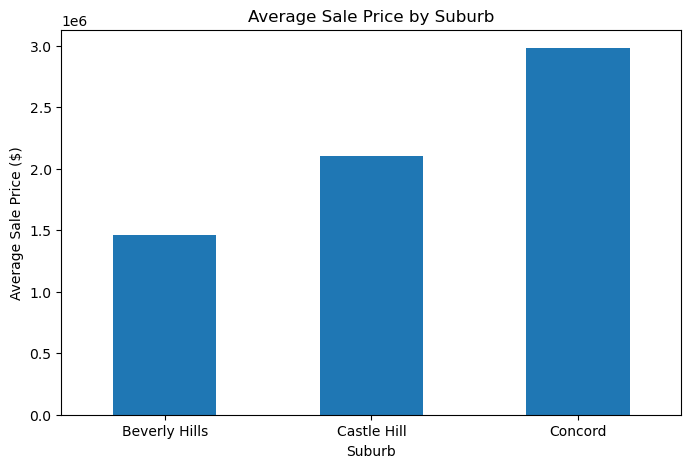

In [36]:
plt.figure(figsize=(8, 5))
df.groupby("suburb")["sale_price"].mean().plot(kind="bar")
plt.xlabel("Suburb")
plt.ylabel("Average Sale Price ($)")
plt.title("Average Sale Price by Suburb")
plt.xticks(rotation=0)
plt.show()

In [37]:
features = [
    "suburb",
    "property_type",
    "bedrooms",
    "bathrooms",
    "total_rooms"
]

X = df[features]
y = df["sale_price"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
          suburb property_type  bedrooms  bathrooms  total_rooms
0  Beverly Hills         Villa       3.0        2.0          5.0
1  Beverly Hills         House       5.0        2.0          7.0
2  Beverly Hills     Apartment       2.0        1.0          3.0
3  Beverly Hills         House       4.0        2.0          6.0
4  Beverly Hills     Apartment       2.0        1.0          3.0

Target:
0    1150000.0
1    2400000.0
2     780000.0
3    1780000.0
4     770000.0
Name: sale_price, dtype: float64


In [38]:
print(X.dtypes)

suburb            object
property_type     object
bedrooms         float64
bathrooms        float64
total_rooms      float64
dtype: object


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (217, 5)
Testing data: (55, 5)


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "suburb",
    "property_type"
]

numeric_features = [
    "bedrooms",
    "bathrooms",
    "total_rooms"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessing setup completed.")

Preprocessing setup completed.


In [41]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_validate

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [42]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

gradient_boosting_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [43]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold cross-validation setup completed.")

5-fold cross-validation setup completed.


In [50]:
df = df.dropna(how="all").copy()
print("Dataset shape after removing empty rows:", df.shape)

Dataset shape after removing empty rows: (105, 13)


In [51]:
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
df["sale_year"] = df["sale_date"].dt.year
df["sale_month"] = df["sale_date"].dt.month
df["days_since_first_sale"] = (df["sale_date"] - df["sale_date"].min()).dt.days

In [52]:
print(df.isnull().sum())

suburb                   0
address                  0
sale_date                1
sale_price               0
property_type            0
bedrooms                 0
bathrooms                0
parking                  0
land_size                1
total_rooms              0
sale_year                1
sale_month               1
days_since_first_sale    1
dtype: int64


In [53]:
features = [
    "suburb",
    "property_type",
    "bedrooms",
    "bathrooms",
    "total_rooms"
]

X = df[features]
y = df["sale_price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (105, 5)
y shape: (105,)


In [54]:
print("Missing sale prices:", y.isnull().sum())

Missing sale prices: 0


In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_features = [
    "suburb",
    "property_type"
]

numeric_features = [
    "bedrooms",
    "bathrooms",
    "total_rooms"
]

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features)
])

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

gradient_boosting_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [57]:
from sklearn.model_selection import KFold

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [58]:
from sklearn.model_selection import cross_validate
import pandas as pd

models = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=kfold,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        }
    )

    results.append({
        "Model": name,
        "MAE": -scores["test_MAE"].mean(),
        "RMSE": -scores["test_RMSE"].mean(),
        "R2": scores["test_R2"].mean()
    })

results_df = pd.DataFrame(results)

print(results_df.round(2))

               Model        MAE       RMSE    R2
0  Linear Regression  436180.57  559891.19  0.74
1      Random Forest  340531.14  456809.88  0.82
2  Gradient Boosting  328845.40  456524.43  0.82


In [59]:
results_df.to_csv("model_comparison_results.csv", index=False)
print("Model comparison results saved.")

Model comparison results saved.


In [60]:
for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=kfold,
        scoring="r2",
        return_train_score=True
    )

    train_r2 = scores["train_score"].mean()
    validation_r2 = scores["test_score"].mean()

    print(name)
    print("Training R2:", round(train_r2, 3))
    print("Validation R2:", round(validation_r2, 3))
    print("Difference:", round(train_r2 - validation_r2, 3))
    print()

Linear Regression
Training R2: 0.828
Validation R2: 0.742
Difference: 0.085

Random Forest
Training R2: 0.948
Validation R2: 0.823
Difference: 0.125

Gradient Boosting
Training R2: 0.954
Validation R2: 0.824
Difference: 0.13



In [61]:
from sklearn.model_selection import cross_val_predict
best_model = gradient_boosting_model

oof_pred = cross_val_predict(
    best_model,
    X,
    y,
    cv=kfold
)

error_df = df[[
    "suburb",
    "address",
    "sale_date",
    "sale_price",
    "property_type",
    "bedrooms",
    "bathrooms"
]].copy()

error_df["predicted_price"] = oof_pred
error_df["absolute_error"] = abs(error_df["sale_price"] - error_df["predicted_price"])
error_df["percentage_error"] = (error_df["absolute_error"] / error_df["sale_price"] * 100)

largest_errors = error_df.sort_values("absolute_error",ascending=False).head(5)
print(largest_errors.to_string(index=False))

     suburb              address  sale_date  sale_price property_type  bedrooms  bathrooms  predicted_price  absolute_error  percentage_error
Castle Hill  60 Womurrung Avenue 2026-09-11   5200000.0         House       5.0        5.0     3.542813e+06    1.657187e+06         31.868986
Castle Hill 61 Cambewarra Avenue 2026-08-25   3550000.0         House       5.0        5.0     5.158407e+06    1.608407e+06         45.307247
    Concord   5 Cormiston Avenue 2026-07-25   3550000.0         House       2.0        2.0     2.210326e+06    1.339674e+06         37.737299
    Concord    38A Empire Avenue 2026-06-16   2200000.0         House       2.0        2.0     3.350047e+06    1.150047e+06         52.274862
    Concord     10A Dally Avenue 2026-07-10   2280000.0 Semi-detached       5.0        4.0     3.359343e+06    1.079343e+06         47.339599


In [62]:
import joblib
best_model = gradient_boosting_model
best_model.fit(X, y)
joblib.dump(best_model, "housing_price_model.pkl")
print("Model saved successfully.")

Model saved successfully.
